# 01 Univariate Distribution Analysis

วัตถุประสงค์: สำรวจการกระจายของตัวแปรสำคัญรายตัว (single-variable behavior) เพื่อเตรียม insight ก่อนทำ bivariate/multivariate EDA

> This notebook focuses on:
- Tenure distribution
- Payment method distribution
- Monthly/Total charge distribution
- Quick churn context checks


## Setup and Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use processed dataset from data preparation phase
df = pd.read_csv('../../../data/processed/telco_customer_churn_clean.csv')

## 1. Tenure Analysis

In [3]:
print(df["tenure"].unique())

print("\n")

print("Min Tenure:", df["tenure"].min())
print("Max Tenure:", df["tenure"].max())

[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]


Min Tenure: 0
Max Tenure: 72


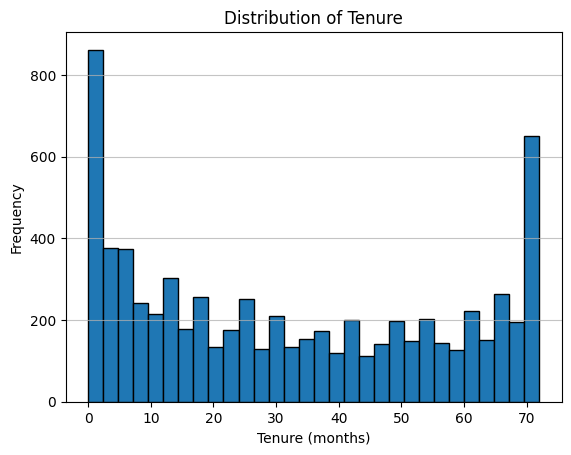

In [4]:
plt.hist(df["tenure"], bins=30, edgecolor='black')
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

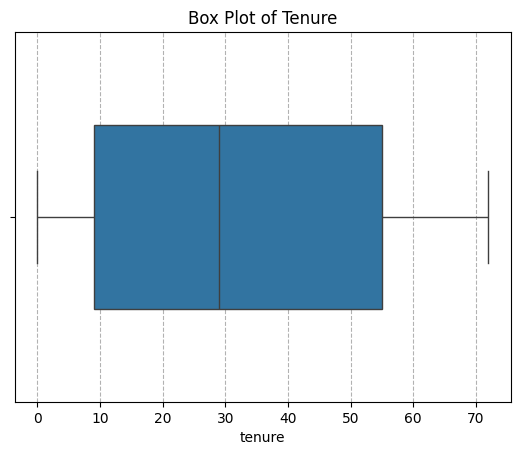

In [5]:
sns.boxplot(x=df["tenure"], showfliers=True, width=0.5)
plt.grid(axis="x", linestyle="--", alpha=0.3, color='black')
plt.title('Box Plot of Tenure')
plt.show()

### Tenure = 0 Analysis: Do new customers churn immediately?

In [6]:
# Check do 0 Tenure always Churn
df[df["tenure"] == df["tenure"].min()]["Churn"] \
    .value_counts().reindex(["Yes", "No"], fill_value=0)

Churn
Yes     0
No     11
Name: count, dtype: int64

**Insight:** ค่า `tenure = 0` ไม่ได้หมายความว่าลูกค้าจะ churn ทุกคนทันที
มีทั้งลูกค้าที่ churn และไม่ churn ซึ่งสะท้อนพฤติกรรมช่วง onboarding ที่ต้องติดตามเชิงกลยุทธ์.

## 2. Payment Method Distribution

In [7]:
df["PaymentMethod"].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [8]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

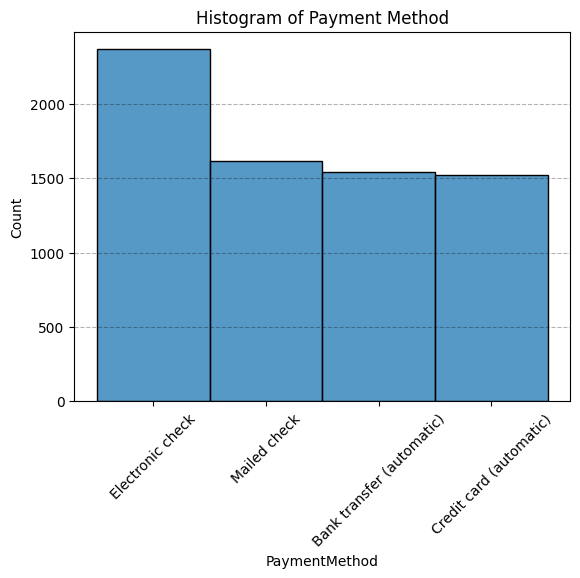

In [9]:
sns.histplot(df["PaymentMethod"], bins=30)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3, color='black')
plt.title('Histogram of Payment Method')
plt.show()

### Payment Method Definitions

- **Electronic check**: ชำระผ่านเช็คอิเล็กทรอนิกส์ (ไม่ใช่ auto-pay เต็มรูปแบบ)
- **Mailed check**: ส่งเช็คทางไปรษณีย์
- **Bank transfer (automatic)**: หักบัญชีธนาคารอัตโนมัติ
- **Credit card (automatic)**: ตัดบัตรเครดิตอัตโนมัติ

นิยามนี้ช่วยเชื่อมผลวิเคราะห์กับ friction ด้านการชำระเงินในมุมธุรกิจ.

## 3. Monthly Charges Distribution

In [10]:
print(df["MonthlyCharges"].unique())

print("\n")

print("Min MonthlyCharge:", df["MonthlyCharges"].min())
print("Max MonthlyCharge:", df["MonthlyCharges"].max())
print("Length of MonthlyCharges:", len(df["MonthlyCharges"].unique()))

[29.85 56.95 53.85 ... 63.1  44.2  78.7 ]


Min MonthlyCharge: 18.25
Max MonthlyCharge: 118.75
Length of MonthlyCharges: 1585


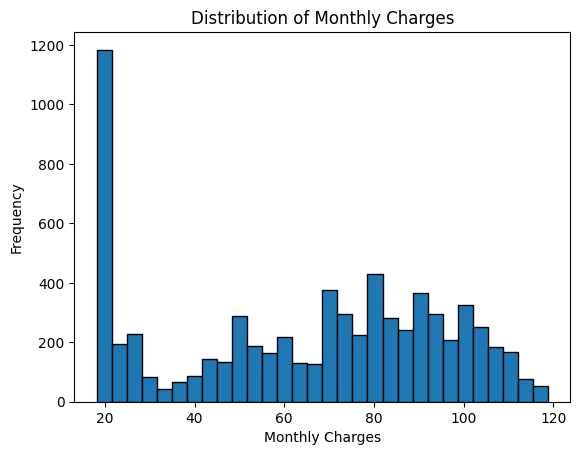

In [11]:
plt.hist(df["MonthlyCharges"], bins=30, edgecolor='black')
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

## 4. Total Charges Overview

`TotalCharges` is already numeric in the processed dataset.

In [12]:
print("TotalCharges statistics:")
print(f"  Min: {df['TotalCharges'].min():.2f}")
print(f"  Max: {df['TotalCharges'].max():.2f}")
print(f"  Mean: {df['TotalCharges'].mean():.2f}")
print(f"  Median: {df['TotalCharges'].median():.2f}")

TotalCharges statistics:
  Min: 18.80
  Max: 8684.80
  Mean: 2283.30
  Median: 1397.47


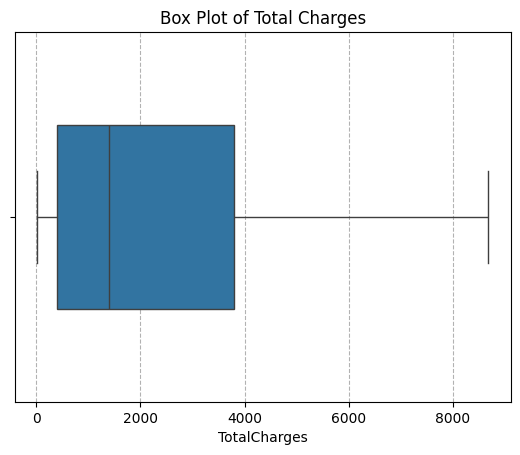

In [13]:
sns.boxplot(x=df["TotalCharges"], showfliers=True, width=0.5)
plt.grid(axis="x", linestyle="--", alpha=0.3, color='black')
plt.title('Box Plot of Total Charges')
plt.show()

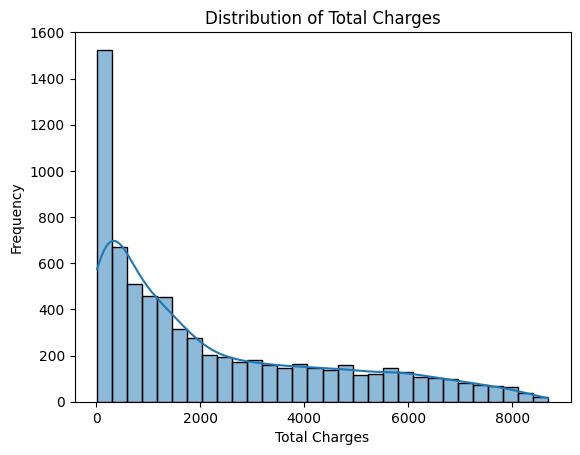

In [18]:
sns.histplot(df["TotalCharges"], bins=30, kde=True)
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")
plt.show()

---

**Next step:** [02_eda_charges.ipynb](02_eda_charges.ipynb)
ไปต่อที่การวิเคราะห์ความสัมพันธ์ระหว่าง charge structure และ churn.